In [1]:
from pathlib import Path

import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

%matplotlib inline
if sns is not None:
    sns.set_theme(style='white')

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'dataset_phase2' / 'dataset_master'
METADATA_PATH = DATA_DIR / 'metadata.csv'
IMAGE_SIZE = (24, 24)

In [3]:
metadata = pd.read_csv(METADATA_PATH)

def get_image_paths(contributor_group, target_class):
    df = metadata.copy()
    target = target_class.lower()
    group = contributor_group.lower()

    df = df[df['final_label'].str.lower() == target]
    m05_mask = df['contributor'].fillna('').str.contains(r'\bM0?5\b', case=False, regex=True)

    if group == 'm05':
        df = df[m05_mask]
    elif group == 'others':
        df = df[~m05_mask]
    else:
        raise ValueError("contributor_group must be 'M05' or 'Others'")

    return [DATA_DIR / path for path in df['image_path']]

In [4]:
def compute_mean_variance_images(image_paths, target_size=IMAGE_SIZE):
    images = []

    for path in image_paths:
        if not path.exists():
            continue
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue
        image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        images.append(image.astype(np.float32))

    if not images:
        empty = np.zeros(target_size, dtype=np.float32)
        return empty, empty

    image_stack = np.stack(images)
    return image_stack.mean(axis=0), image_stack.var(axis=0)

In [5]:
eda_groups = [
    ('M05', 'Open', 'open'),
    ('M05', 'Closed', 'closed'),
    ('Others', 'Open', 'open'),
    ('Others', 'Closed', 'closed'),
]

image_stats = []
for contributor_group, class_label, target_class in eda_groups:
    paths = get_image_paths(contributor_group, target_class)
    mean_image, variance_image = compute_mean_variance_images(paths)
    image_stats.append({
        'title': f'{contributor_group}-{class_label}',
        'count': len(paths),
        'mean': mean_image,
        'variance': variance_image,
    })

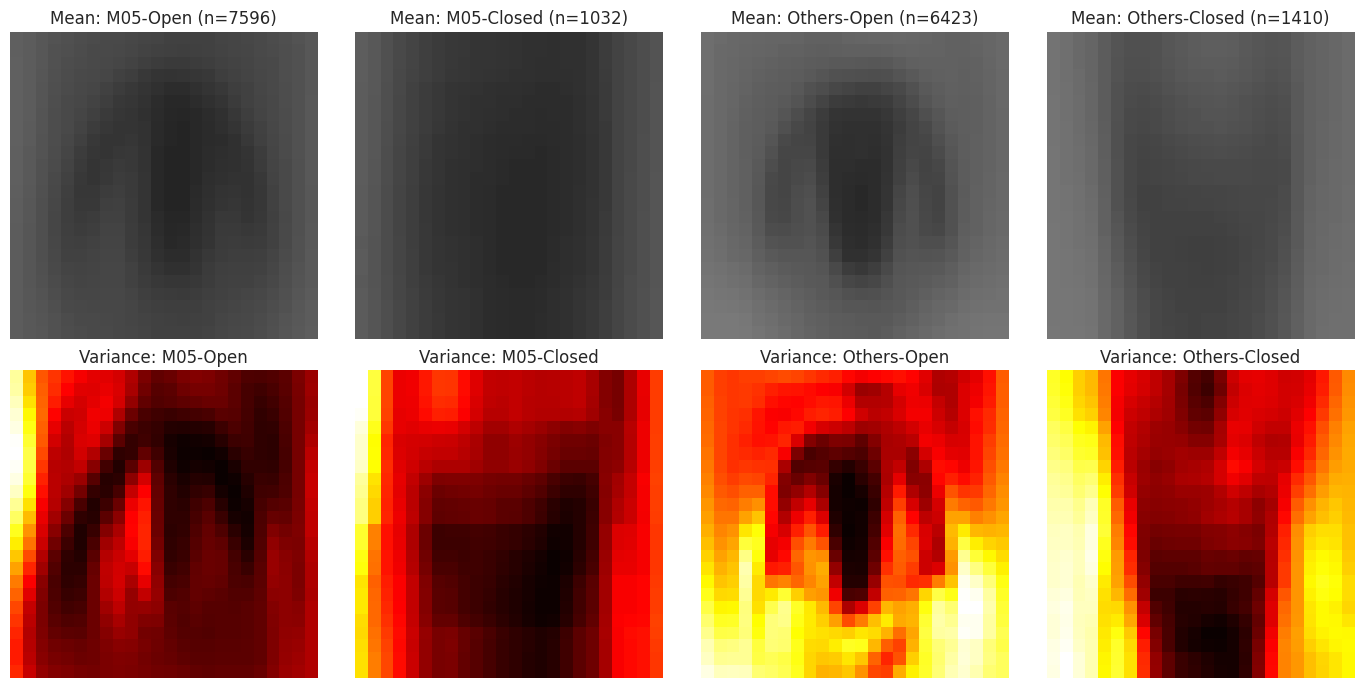

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for index, stats in enumerate(image_stats):
    axes[0, index].imshow(stats['mean'], cmap='gray', vmin=0, vmax=255)
    axes[0, index].set_title(f"Mean: {stats['title']} (n={stats['count']})")
    axes[0, index].axis('off')

    axes[1, index].imshow(stats['variance'], cmap='hot')
    axes[1, index].set_title(f"Variance: {stats['title']}")
    axes[1, index].axis('off')

plt.tight_layout()
plt.show()

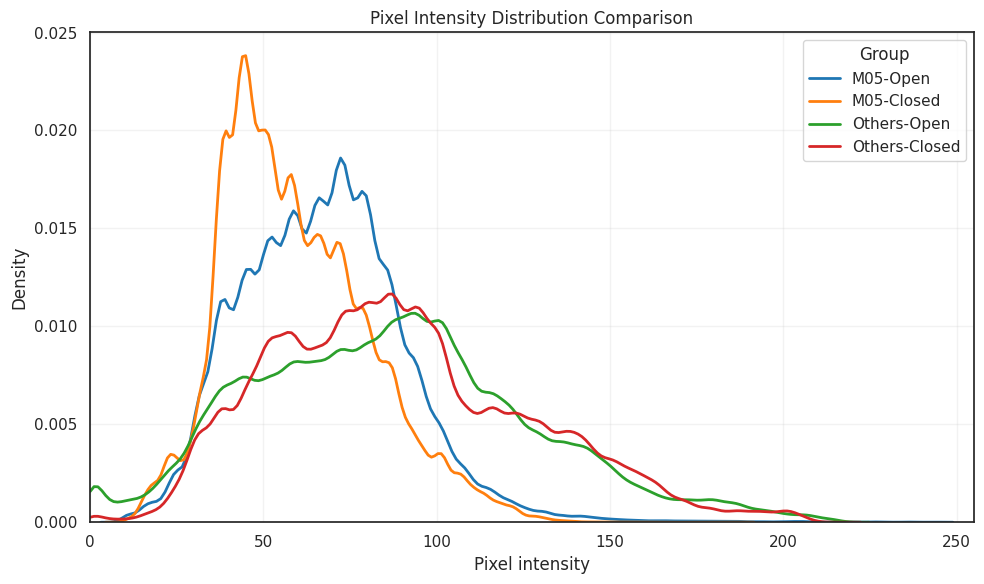

In [7]:
PIXEL_SAMPLE_LIMIT = 1000
pixel_rng = np.random.default_rng(42)

pixel_groups = [
    ('M05-Open', 'M05', 'open', '#1f77b4'),
    ('M05-Closed', 'M05', 'closed', '#ff7f0e'),
    ('Others-Open', 'Others', 'open', '#2ca02c'),
    ('Others-Closed', 'Others', 'closed', '#d62728'),
]

pixel_distributions = {}
for label, contributor_group, target_class, color in pixel_groups:
    image_paths = get_image_paths(contributor_group, target_class)
    if len(image_paths) > PIXEL_SAMPLE_LIMIT:
        sample_indices = pixel_rng.choice(len(image_paths), size=PIXEL_SAMPLE_LIMIT, replace=False)
        image_paths = [image_paths[index] for index in sample_indices]

    flattened_pixels = []
    for path in image_paths:
        if not path.exists():
            continue
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue
        image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
        flattened_pixels.append(image.reshape(-1))

    pixels = np.concatenate(flattened_pixels).astype(np.float32) if flattened_pixels else np.array([], dtype=np.float32)
    pixel_distributions[label] = {'pixels': pixels, 'color': color}

def plot_pixel_intensity_distribution(use_kde=True):
    fig, ax = plt.subplots(figsize=(10, 6))

    for label, values in pixel_distributions.items():
        pixels = values['pixels']
        if pixels.size == 0:
            continue

        if use_kde:
            sns.kdeplot(
                x=pixels,
                ax=ax,
                label=label,
                color=values['color'],
                clip=(0, 255),
                bw_adjust=0.8,
                linewidth=2,
                warn_singular=False,
            )
        else:
            ax.hist(
                pixels,
                bins=64,
                range=(0, 255),
                density=True,
                histtype='step',
                linewidth=2,
                label=label,
                color=values['color'],
            )

    ax.set_title('Pixel Intensity Distribution Comparison')
    ax.set_xlabel('Pixel intensity')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 255)
    ax.legend(title='Group')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    return fig, ax

try:
    if sns is None:
        raise ImportError('seaborn unavailable')
    fig, ax = plot_pixel_intensity_distribution(use_kde=True)
except Exception:
    if 'fig' in locals():
        plt.close(fig)
    fig, ax = plot_pixel_intensity_distribution(use_kde=False)

plt.show()


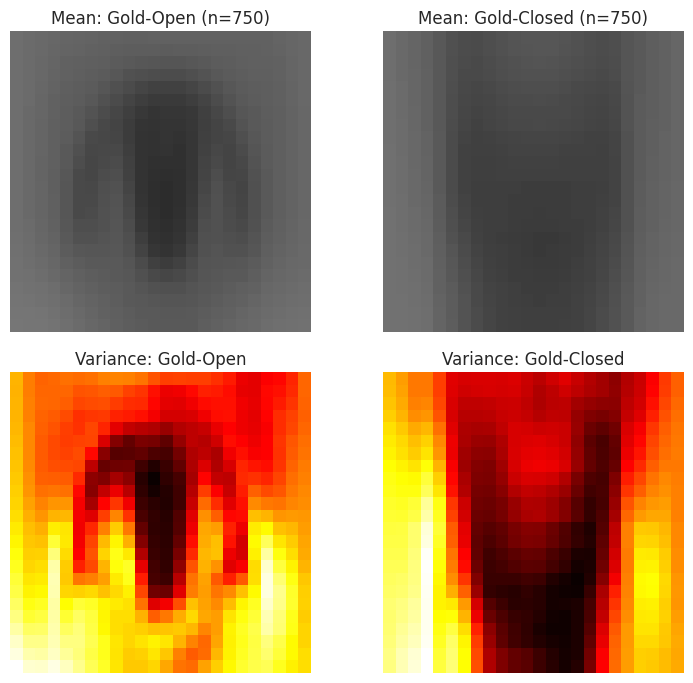

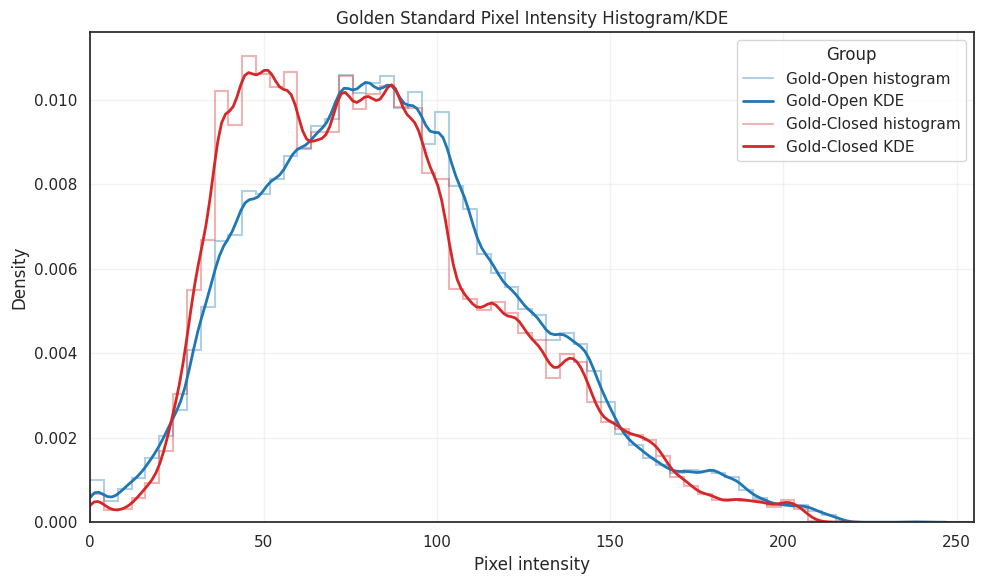

In [9]:
import re

GOLD_RANDOM_STATE = 2026
GOLD_SAMPLE_SIZE = 125
GOLD_MEMBERS = [f'M{member_number:02d}' for member_number in range(1, 7)]
GOLD_CLASSES = ['open', 'closed']


def identify_gold_member(contributor):
    text = '' if pd.isna(contributor) else str(contributor)

    for member_number in range(1, 7):
        if re.search(rf'(?<![A-Za-z0-9])M0?{member_number}(?![A-Za-z0-9])', text, flags=re.IGNORECASE):
            return f'M{member_number:02d}'

    return np.nan


def resolve_gold_image_path(image_path):
    if pd.isna(image_path):
        return None

    path_text = str(image_path).strip().replace('\\', '/')
    if not path_text:
        return None

    path_obj = Path(path_text)
    candidates = []

    if path_obj.is_absolute() and path_obj.exists():
        candidates.append(path_obj)
    elif not re.match(r'^[A-Za-z]:/', path_text):
        candidates.append(DATA_DIR / path_text)

    if '/raw_eyes/' in path_text:
        candidates.append(DATA_DIR / 'raw_eyes' / path_text.rsplit('/raw_eyes/', 1)[1])

    candidates.append(DATA_DIR / 'raw_eyes' / path_obj.name)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


gold_metadata = metadata.copy()
gold_metadata['gold_member'] = gold_metadata['contributor'].apply(identify_gold_member)
gold_metadata['gold_class'] = gold_metadata['final_label'].fillna('').astype(str).str.strip().str.lower()
gold_metadata = gold_metadata[
    gold_metadata['gold_member'].isin(GOLD_MEMBERS)
    & gold_metadata['gold_class'].isin(GOLD_CLASSES)
].copy()
gold_metadata['gold_image_path'] = gold_metadata['image_path'].apply(resolve_gold_image_path)
gold_metadata = gold_metadata[gold_metadata['gold_image_path'].notna()].copy()

gold_rng = np.random.default_rng(GOLD_RANDOM_STATE)
gold_samples = []

for member in GOLD_MEMBERS:
    for target_class in GOLD_CLASSES:
        subset = gold_metadata[
            (gold_metadata['gold_member'] == member)
            & (gold_metadata['gold_class'] == target_class)
        ]

        if len(subset) < GOLD_SAMPLE_SIZE:
            raise ValueError(f'{member}-{target_class} has {len(subset)} images; {GOLD_SAMPLE_SIZE} required')

        sampled_subset = subset.sample(
            n=GOLD_SAMPLE_SIZE,
            random_state=int(gold_rng.integers(0, 2**31 - 1)),
        ).copy()
        sampled_subset['gold_group'] = f'Gold-{target_class.title()}'
        gold_samples.append(sampled_subset)

gold_sample = pd.concat(gold_samples, ignore_index=True)
gold_counts = gold_sample.pivot_table(
    index='gold_member',
    columns='gold_class',
    values='gold_image_path',
    aggfunc='size',
).loc[GOLD_MEMBERS, GOLD_CLASSES]
gold_group_counts = gold_sample['gold_group'].value_counts().sort_index()

assert (gold_counts == GOLD_SAMPLE_SIZE).all().all()
assert gold_group_counts.to_dict() == {'Gold-Closed': 750, 'Gold-Open': 750}


def load_gold_image_stack(image_paths, target_size=IMAGE_SIZE):
    images = []

    for path in image_paths:
        if not path.exists():
            raise FileNotFoundError(path)

        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f'Unable to read image: {path}')

        image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        images.append(image.astype(np.float32))

    return np.stack(images)


gold_group_order = ['Gold-Open', 'Gold-Closed']
gold_image_stats = {}
gold_pixel_histograms = {}
gold_pixel_distributions = {}

for group_label in gold_group_order:
    group_paths = gold_sample.loc[gold_sample['gold_group'] == group_label, 'gold_image_path'].tolist()
    image_stack = load_gold_image_stack(group_paths)
    pixels = image_stack.reshape(-1)
    hist_density, hist_edges = np.histogram(pixels, bins=64, range=(0, 255), density=True)

    gold_image_stats[group_label] = {
        'count': len(group_paths),
        'mean': image_stack.mean(axis=0),
        'variance': image_stack.var(axis=0),
    }
    gold_pixel_histograms[group_label] = {
        'density': hist_density,
        'edges': hist_edges,
    }
    gold_pixel_distributions[group_label] = pixels

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

for column, group_label in enumerate(gold_group_order):
    stats = gold_image_stats[group_label]

    axes[0, column].imshow(stats['mean'], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    axes[0, column].set_title(f"Mean: {group_label} (n={stats['count']})")
    axes[0, column].axis('off')

    axes[1, column].imshow(stats['variance'], cmap='hot', interpolation='nearest')
    axes[1, column].set_title(f'Variance: {group_label}')
    axes[1, column].axis('off')

plt.tight_layout()
plt.show()

gold_colors = {'Gold-Open': '#1f77b4', 'Gold-Closed': '#d62728'}
fig, ax = plt.subplots(figsize=(10, 6))

for group_label in gold_group_order:
    histogram = gold_pixel_histograms[group_label]
    pixels = gold_pixel_distributions[group_label]
    ax.stairs(
        histogram['density'],
        histogram['edges'],
        color=gold_colors[group_label],
        alpha=0.35,
        linewidth=1.5,
        label=f'{group_label} histogram',
    )

    sns.kdeplot(
        x=pixels,
        ax=ax,
        label=f'{group_label} KDE',
        color=gold_colors[group_label],
        clip=(0, 255),
        bw_adjust=0.8,
        linewidth=2,
        warn_singular=False,
    )

ax.set_title('Golden Standard Pixel Intensity Histogram/KDE')
ax.set_xlabel('Pixel intensity')
ax.set_ylabel('Density')
ax.set_xlim(0, 255)
ax.legend(title='Group')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


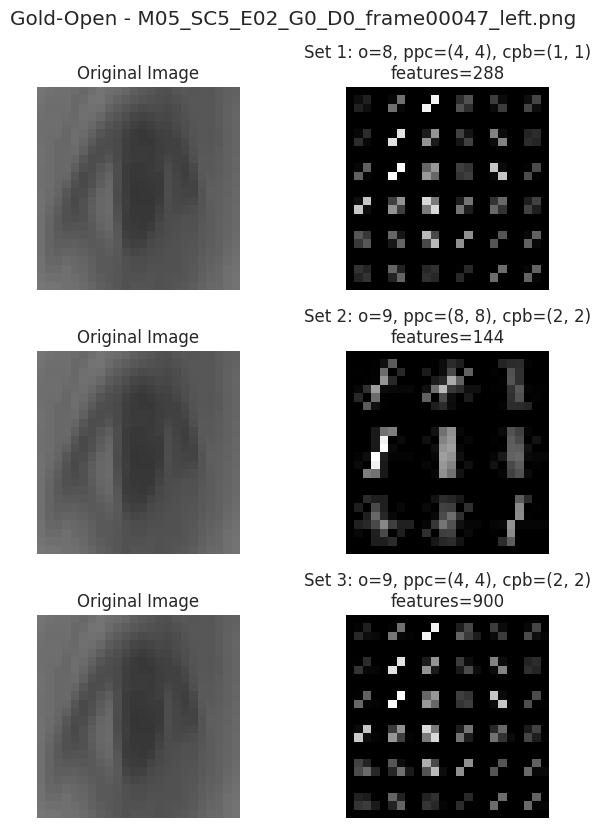

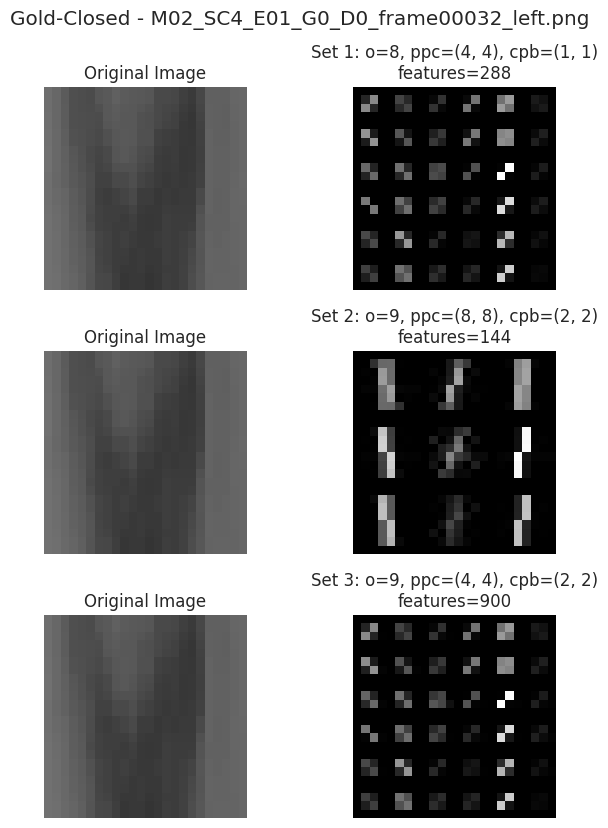

In [12]:
# HOG Parameter Tuning
from skimage import exposure
from skimage.feature import hog

hog_param_list = [
    {'orientations': 8, 'pixels_per_cell': (4, 4), 'cells_per_block': (1, 1)},
    {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)},
    {'orientations': 9, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2)},
]

hog_representative_groups = ['Gold-Open', 'Gold-Closed']

def load_representative_image(gold_group, target_size=IMAGE_SIZE):
    subset = gold_sample.loc[gold_sample['gold_group'] == gold_group]
    images = []
    valid_paths = []

    for path in subset['gold_image_path']:
        path = Path(path)
        if not path.exists():
            continue
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue
        image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        images.append(image)
        valid_paths.append(path)

    if not images:
        raise ValueError(f'No valid images found for {gold_group}')

    image_stack = np.stack([image.astype(np.float32) for image in images])
    mean_image = image_stack.mean(axis=0)
    distances = np.mean((image_stack - mean_image) ** 2, axis=(1, 2))
    representative_index = int(np.argmin(distances))

    return images[representative_index], valid_paths[representative_index]

def compute_hog_image(img, params):
    hog_features, hog_image = hog(
        img,
        visualize=True,
        feature_vector=True,
        **params,
    )

    if np.ptp(hog_image) > 0:
        hog_image = exposure.rescale_intensity(hog_image, in_range='image', out_range=(0, 1))

    return hog_features, hog_image

def plot_hog_comparison(img, param_list):
    fig, axes = plt.subplots(len(param_list), 2, figsize=(7, 2.7 * len(param_list)), squeeze=False)

    for index, params in enumerate(param_list):
        hog_features, hog_image = compute_hog_image(img, params)
        param_title = (
            f"Set {index + 1}: o={params['orientations']}, "
            f"ppc={params['pixels_per_cell']}, cpb={params['cells_per_block']}"
        )

        axes[index, 0].imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        axes[index, 0].set_title('Original Image')
        axes[index, 0].axis('off')

        axes[index, 1].imshow(hog_image, cmap='gray', interpolation='nearest')
        axes[index, 1].set_title(f'{param_title}\nfeatures={hog_features.size}')
        axes[index, 1].axis('off')

    plt.tight_layout()
    return fig, axes

representative_images = []
for group_label in hog_representative_groups:
    image, image_path = load_representative_image(group_label)
    representative_images.append({
        'label': group_label,
        'image': image,
        'path': image_path,
    })

for sample in representative_images:
    fig, axes = plot_hog_comparison(sample['image'], hog_param_list)
    fig.suptitle(f"{sample['label']} - {sample['path'].name}", y=1.02)
    plt.show()


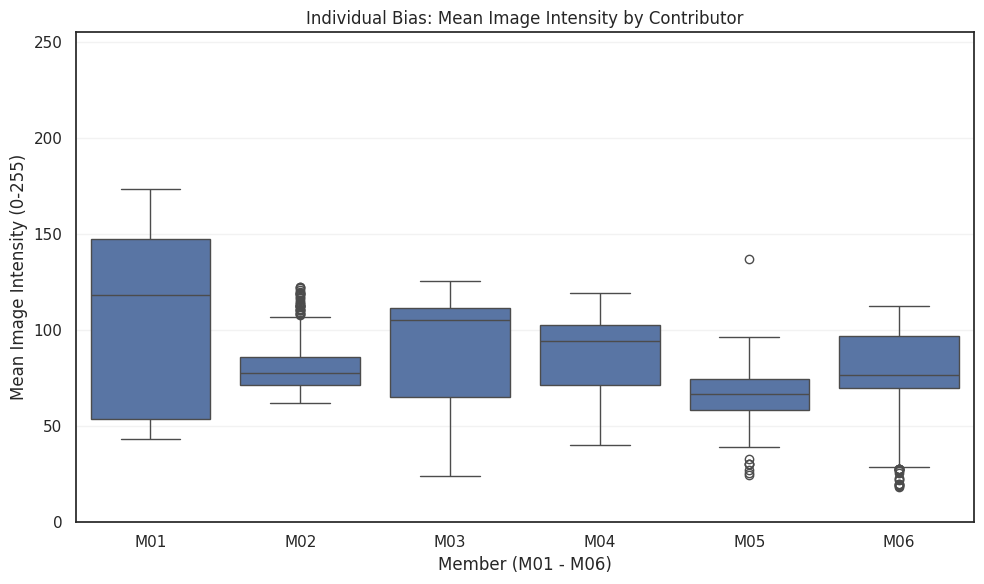

In [11]:
# Individual Bias Analysis
import re

INDIVIDUAL_RANDOM_STATE = 2026
INDIVIDUAL_SAMPLE_SIZE = 200
INDIVIDUAL_MEMBERS = [f'M{member_number:02d}' for member_number in range(1, 7)]


def identify_individual_member(contributor):
    text = '' if pd.isna(contributor) else str(contributor)

    for member_number in range(1, 7):
        if re.search(rf'(?<![A-Za-z0-9])M0?{member_number}(?![A-Za-z0-9])', text, flags=re.IGNORECASE):
            return f'M{member_number:02d}'

    return np.nan


def resolve_individual_image_path(image_path):
    if pd.isna(image_path):
        return None

    path_text = str(image_path).strip().replace('\\', '/')
    if not path_text:
        return None

    path_obj = Path(path_text)
    candidates = []

    if path_obj.is_absolute() and path_obj.exists():
        candidates.append(path_obj)
    elif not re.match(r'^[A-Za-z]:/', path_text):
        candidates.append(DATA_DIR / path_text)

    if '/raw_eyes/' in path_text:
        candidates.append(DATA_DIR / 'raw_eyes' / path_text.rsplit('/raw_eyes/', 1)[1])

    candidates.append(DATA_DIR / 'raw_eyes' / path_obj.name)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


individual_metadata = metadata.copy()
individual_metadata['member'] = individual_metadata['contributor'].apply(identify_individual_member)
individual_metadata = individual_metadata[individual_metadata['member'].isin(INDIVIDUAL_MEMBERS)].copy()
individual_metadata['resolved_image_path'] = individual_metadata['image_path'].apply(resolve_individual_image_path)
individual_metadata = individual_metadata[individual_metadata['resolved_image_path'].notna()].copy()

individual_rng = np.random.default_rng(INDIVIDUAL_RANDOM_STATE)
individual_intensity_records = []

for member in INDIVIDUAL_MEMBERS:
    member_images = individual_metadata[individual_metadata['member'] == member]

    if len(member_images) < INDIVIDUAL_SAMPLE_SIZE:
        raise ValueError(f'{member} has {len(member_images)} images; {INDIVIDUAL_SAMPLE_SIZE} required')

    sampled_images = member_images.sample(
        n=INDIVIDUAL_SAMPLE_SIZE,
        random_state=int(individual_rng.integers(0, 2**31 - 1)),
    )

    for image_path in sampled_images['resolved_image_path']:
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f'Unable to read image: {image_path}')

        individual_intensity_records.append({
            'Member': member,
            'Mean Image Intensity': float(image.mean()),
        })

individual_intensity_df = pd.DataFrame(individual_intensity_records)

if sns is None:
    raise ImportError('seaborn is required for the individual bias boxplot')

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=individual_intensity_df,
    x='Member',
    y='Mean Image Intensity',
    order=INDIVIDUAL_MEMBERS,
    ax=ax,
)

ax.set_title('Individual Bias: Mean Image Intensity by Contributor')
ax.set_xlabel('Member (M01 - M06)')
ax.set_ylabel('Mean Image Intensity (0-255)')
ax.set_ylim(0, 255)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
